<div style="background-color: #f8f8f8; border: 2px solid #333; border-radius: 12px; padding: 30px; margin: 15px 0;">

<h1 style="text-align:center; margin:0 0 20px 0; font-size:28px;">
Rain Gauge Optimisation in the Upper Severn
</h1>

<div style="text-align:left; line-height:1.6;">

<p>
This script identifies optimal locations for the installation of new rain gauges
within the Upper Severn catchment.
</p>

<p>
The selected gauge locations are designed to satisfy the following criteria:
</p>

<ul>
    <li>
        <b>Terrain representation:</b> sample across the range of topographic
        conditions present within the catchment.
    </li>
    <li>
        <b>Radar-grid representativeness:</b> represent the terrain characteristics
        of the surrounding 1 km radar-rainfall grid cell. This reduces the risk that
        radar–gauge comparisons at 1 km resolution are biased by a gauge sampling an
        atypical microsite.
    </li>
    <li>
        <b>Spatial separation:</b> maintain a minimum separation distance of
        approximately 2.5–3 km between gauges.
    </li>
</ul>


<h2 style="margin-top:25px;">
Methodology
</h2>

<ol>

<li>
<b>Cluster analysis at two spatial resolutions</b>

<p>
K-means clustering is applied independently to elevation and slope at two
resolutions:
</p>

<ul>
    <li>
        <b>30 m resolution:</b> using the native DEM resolution to identify
        fine-scale terrain classes.
    </li>
    <li>
        <b>1 km resolution:</b> using mean elevation and slope within each
        radar-rainfall grid cell to identify broader terrain classes.
    </li>
</ul>

<p>
This produces two complementary representations of catchment terrain variability.
</p>

</li>


<li>
<b>Calculate 30 m terrain purity within each 1 km cell</b>

<p>
For each 1 km grid cell, the proportion of constituent 30 m cells belonging to the
same dominant 30 m cluster is calculated.
</p>

<p>
This produces a <b>terrain purity score</b>, describing how internally
homogeneous each 1 km cell is at fine spatial resolution.
</p>

</li>


<li>
<b>Select candidate 1 km grid cells for new gauges</b>

<p>
For each 1 km terrain cluster, the aim is to achieve a minimum gauge density of
two gauges per cluster (existing plus newly proposed locations).
</p>

<p>
New gauges are preferentially located within 1 km cells that:
</p>

<ul>
    <li>
        belong to the target 1 km terrain cluster;
    </li>
    <li>
        have high 30 m terrain purity, ensuring the cell provides a representative
        sample of that terrain type rather than a mixture of contrasting landscapes;
    </li>
    <li>
        maintain the required minimum distance from all existing and proposed gauges.
    </li>
</ul>

</li>


<li>
<b>Select the final 30 m gauge location within each 1 km cell</b>

<p>
Within each selected 1 km grid cell, the optimal 30 m installation location is
identified by selecting the pixel whose elevation and slope are closest to the
mean elevation and slope characteristics of the surrounding 1 km cell (while staying within the minimum distance criteria)
</p>
    
   

</li>

<li>
<b>Select backup 30 m gauge location within each 1 km cell</b>

<p>
Within each selected 1 km grid cell, backup 30 m installation locations are
identified by finding the 30m grid cells with the next closest elevation and slope values to the mean of the cell
</p>
    
   

</li>    
    
    
</ol>


</div>
</div>

In [22]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import importlib
import matplotlib.colors as mcolors
import matplotlib
from matplotlib.patches import Patch
import random
import rioxarray
import rasterio
from rasterio.features import rasterize
from rasterio.mask import mask
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from matplotlib.lines import Line2D
from IPython.display import display

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"
catchment_Dolwen = gpd.read_file(data_dir + "54080/54080.shp")

import functions
importlib.reload(functions)
from functions import *   # expects: is_feasible, greedy_selection_multi (or greedy_selection), score

In [105]:
# landcover_path = data_dir + "lmc2023 clip.tif"

# src = rasterio.open(landcover_path)
# landcover = src.read(1)  # read first band

# # Ensure CRS matches
# catchment_Dolwen = catchment_Dolwen.to_crs(src.crs)

# # Convert geometry to GeoJSON-like format
# geoms = catchment_Dolwen.geometry.values

# clipped, transform = mask(src, geoms, crop=True)
# clipped = clipped[0]  # first band

# # Mask zeros
# clipped_masked = np.ma.masked_where(clipped == 0, clipped);

In [106]:
# classes = np.unique(landcover)
# classes = classes[classes != 0]  # optional: drop 0 if it's background

# cmap = plt.get_cmap("tab20", len(classes))

# norm = mcolors.BoundaryNorm( boundaries=np.append(classes, classes[-1] + 1), ncolors=len(classes))

# landcover_masked = np.ma.masked_where(landcover == 0, landcover)

# cmap = cmap.copy()
# cmap.set_bad(color="none")

# plt.imshow(landcover_masked, cmap=cmap, norm=norm)

# cbar = plt.colorbar(ticks=classes)
# cbar.set_label("Landcover class")

# plt.axis("off");

In [4]:
# --------------------------------------------------
# Load dataset containing locations of existing gauges +
# --------------------------------------------------
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")
rain_meta_sf = gpd.GeoDataFrame(
    rain_meta_cmd,
    geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
    crs="EPSG:27700")

rainfall_gdf_merged = gpd.read_file(data_dir + "Derived/rainfall_gdf_merged.gpkg")

<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    

--- 

## 1. Run cluster analysis at 2 resolutions to produce two separate cluster typologies: 
30m (native resolution) and 1km resolution

---

</div>

## 1km

In [5]:
# Decide features to cluster on
feature_cols = ["mean_dem", "mean_slope"]

# Remove rows with NA values
valid_mask_1km = rainfall_gdf_merged[feature_cols].notna().all(axis=1)
rainfall_gdf_valid = rainfall_gdf_merged.loc[valid_mask_1km].reset_index(drop=True)

# Get the feature columns and appply a scaler
features_1km = rainfall_gdf_valid[feature_cols]
scaler_1km = StandardScaler()
X_1km = scaler_1km.fit_transform(features_1km)

# Apply kmeans clustering
k = 5
kmeans_1km = KMeans(n_clusters=k, random_state=0)
labels_1km = kmeans_1km.fit_predict(X_1km)

# Apply cluster labels back to dataframe
rainfall_gdf_valid["cluster"] = labels_1km
rainfall_gdf_valid["zone_id"] = np.arange(len(rainfall_gdf_valid))

## 30m

In [6]:
# Get 30m elevation data
dem_path = data_dir + "dem_Dolwen.tif"
with rioxarray.open_rasterio(dem_path, masked=True) as dem_rx:
    dem = dem_rx.squeeze()
    dem_arr = dem.values.astype(float)
    transform = dem.rio.transform()

# Create 30m slope data
dx = transform.a
dy = -transform.e
dz_dy, dz_dx = np.gradient(dem_arr, dy, dx)
slope_arr = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

# Mask out columns with NAN values
valid_mask_30m = ~np.isnan(dem_arr) & ~np.isnan(slope_arr)
features_30m = np.column_stack([dem_arr[valid_mask_30m], slope_arr[valid_mask_30m]])

# Scale the features
scaler_30m = StandardScaler()
X_30m = scaler_30m.fit_transform(features_30m)

# Run kmeans clustering
k_30m = 5
kmeans_30m = KMeans(n_clusters=k_30m, random_state=0)
labels_30m = kmeans_30m.fit_predict(X_30m)

# Place 30m labels back into full 2D grid shape
labels_30m_full = np.full(dem_arr.shape, -1, dtype=int)
labels_30m_full[valid_mask_30m] = labels_30m

<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    

--- 

## 2. Compute 30m purity per 1km grid cell

---

</div>

In [7]:
# Rasterize 1km cells onto the 30m DEM grid (i.e. convert from vector polygons to a raster layer) 
# so every 30m pixel knows which 1km cell (zone_id) it falls inside
zone_raster = rasterize([(geom, zid) for geom, zid in zip(rainfall_gdf_valid.geometry, rainfall_gdf_valid["zone_id"])],
    out_shape=dem_arr.shape, transform=transform, fill=-1, dtype="int32")

# Combine zone_id + 30m cluster label for every valid 30m pixel
combined_mask = valid_mask_30m & (zone_raster >= 0)

# For every valid 30m pixel create a row in a dataframe with the zone ID and the 30m cluster label
pixel_df = pd.DataFrame({"zone_id": zone_raster[combined_mask],"cluster_30m": labels_30m_full[combined_mask],})

# Find the count/proportion of each cluster label in each zone
counts = pixel_df.groupby(["zone_id", "cluster_30m"]).size().unstack(fill_value=0)
proportions = counts.div(counts.sum(axis=1), axis=0)

# Find the maximum proportion across the clusters, and what the dominant 30m cluster is
purity = proportions.max(axis=1)
dominant_30m_cluster = proportions.idxmax(axis=1)

# Add to dataframe of rainfall data
rainfall_gdf_valid["purity"] = rainfall_gdf_valid["zone_id"].map(purity)
rainfall_gdf_valid["dominant_30m_cluster"] = rainfall_gdf_valid["zone_id"].map(dominant_30m_cluster)

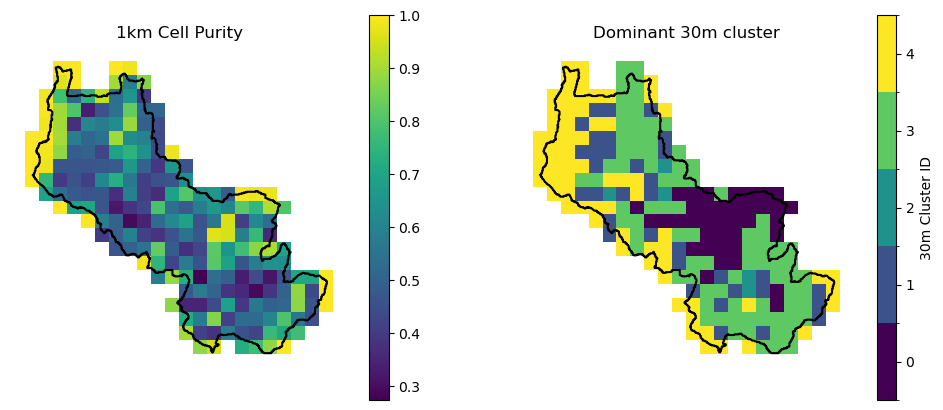

In [8]:
fig, axs = plt.subplots(ncols = 2, figsize=(12, 5))

rainfall_gdf_valid.plot(column="purity", cmap="viridis", legend=True, ax=axs[0])

catchment_Dolwen.boundary.plot(ax=axs[0], color="black")
axs[0].set_title("1km Cell Purity")
axs[0].axis("off");

# Define discrete colormap (5 clusters → 5 colours)
cmap = plt.get_cmap("viridis", 5)

# Define boundaries so each integer gets its own colour bin
bounds = np.arange(-0.5, 5.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot
rainfall_gdf_valid.plot(column="dominant_30m_cluster",cmap=cmap,norm=norm,legend=False,ax=axs[1])

catchment_Dolwen.boundary.plot(ax=axs[1], color="black")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

cbar = plt.colorbar(sm, ax=axs[1], boundaries=bounds, ticks=range(5))
cbar.set_label("30m Cluster ID")

axs[1].set_title("Dominant 30m cluster")
axs[1].axis("off"); 

<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    
--- 

## 3. Select new gauge locations

---    
    
For each 1km-resolution cluster, ensure it contains 2 gauges in total (existing + new). New gauges should be placed within 1km cells that:

- Belong to the target 1km cluster, and
- Have high 30m purity (i.e. the cell is a genuinely representative, internally consistent sample of that terrain type, not a diluted mix), and
- Maintain a minimum spacing from all other gauge locations (existing and newly proposed).
    

</div>

---

###  Assign existing gauges to 1km cells + clusters

---

In [116]:
gauge_with_cells = gpd.sjoin(rain_meta_sf,
                             rainfall_gdf_valid[["geometry", "cluster", "purity", "zone_id", "mean_dem", "mean_slope"]],
    how="inner",predicate="within").reset_index(drop=True)

existing_counts = gauge_with_cells["cluster"].value_counts().reindex(range(k), fill_value=0)

---

### Find the number of new gauges needed in each cluster.

This is based on an assumption of each cluster having the same number of gauges. 

Alternatives:  
- Proportional assignment to clusters based on coverage of the catchment  
- Relevance of clusters to rainfall-runoff relationships?

---

In [11]:
# Define how many new gauges are needed in each cluster
n_existing = 8
n_total_final = 18
n_new = n_total_final - n_existing
target_quota = pd.Series(n_total_final / k, index=range(k))

# Only existing gauges sitting in high-purity cells count toward "fulfilling" a cluster's quota.
# Low-purity existing gauges still exist (and still take up space for min_dist purposes later),
# but don't reduce how many well-placed gauges the cluster still needs
purity_threshold = 0.6
gauge_with_cells["well_covered"] = gauge_with_cells["purity"] >= purity_threshold
effective_existing_counts = (gauge_with_cells[gauge_with_cells["well_covered"]]["cluster"]
    .value_counts()
    .reindex(range(k), fill_value=0))

# Define how many new gauges are needed (accounting for existing ones which don't meet purity threshold)
new_needed = pd.Series(0, index=range(k))
for _ in range(n_new):
    current_total = effective_existing_counts + new_needed
    gap = target_quota - current_total
    target_cluster = gap.idxmax()
    new_needed[target_cluster] += 1

# Create summary table
summary = pd.DataFrame({ "target_quota": target_quota.round(2),
    "all_existing": gauge_with_cells["cluster"].value_counts().reindex(range(k), fill_value=0),
    "high_purity_existing": effective_existing_counts, "new_needed": new_needed,})

summary.index.name = "cluster"
summary.loc["TOTAL"] = summary.sum()
summary = summary.astype({"all_existing": int, "high_purity_existing": int, "new_needed": int})
assert new_needed.sum() == n_new
display(summary)

,target_quota,all_existing,high_purity_existing,new_needed
cluster,,,,
0,3.6,2,1,2
1,3.6,2,0,3
2,3.6,0,0,3
3,3.6,2,2,1
4,3.6,2,2,1
TOTAL,18.0,8,5,10


---

### Find the 1km cells in which to place the new gauges

This involves ranking 1km cells within each cluster by purity, then greedily selecting enough cells per cluster (respecting min_dist) to meet quota

---

In [12]:
min_dist = 3000  # metres

# Get the coordinates of the existing gauges
existing_coords = np.column_stack([gauge_with_cells.geometry.x.values, gauge_with_cells.geometry.y.values])

# Get the centroid coordinates of the 1km cells
#     for the min_dist spacing check between candidate CELLS (coarse check) — fine-grained 30m check happens after
cell_centroids = np.column_stack([rainfall_gdf_valid.geometry.centroid.x.values, rainfall_gdf_valid.geometry.centroid.y.values])

# Greedily select new gauge locations within each cluster, prioritising
# high-purity 1km cells, subject to a minimum-distance feasibility
# constraint against both the existing network and gauges already
# selected in this pass (including from other clusters).

selected_zone_ids_per_cluster = {c: [] for c in range(k)}
all_selected_idx = []   # indices into rainfall_gdf_valid, across all clusters
                         # (shared/running list so gauges from different
                         # clusters can't end up too close to each other)

for cluster_id in range(k):
    n_needed = int(new_needed[cluster_id])
    if n_needed == 0:
        continue

    # Candidate cells belonging to this cluster only
    cluster_cells = rainfall_gdf_valid[rainfall_gdf_valid["cluster"] == cluster_id]

    # Rank candidates by purity, most homogeneous first -- these are
    # tried before less "pure" cells
    ranked_idx = cluster_cells.sort_values("purity", ascending=False).index.tolist()

    count = 0
    for idx in ranked_idx:
        if count >= n_needed:
            break  # this cluster's quota is filled

        candidate_xy = cell_centroids[idx]

        # Feasibility = respects min_dist from existing gauges AND from
        # every gauge selected so far in this run (all clusters combined)
        if is_feasible(candidate_xy, all_selected_idx, cell_centroids, existing_coords, min_dist):
            selected_zone_ids_per_cluster[cluster_id].append(idx)
            all_selected_idx.append(idx)
            count += 1
        # else: candidate rejected for spacing, move to next-best-purity cell
        # NOTE: no backtracking -- an early greedy pick can block a better
        # later configuration; this is a single deterministic pass

    if count < n_needed:
        # Ran out of ranked candidates before hitting quota, almost always
        # because remaining high-purity cells were too close to something
        # already chosen
        print(f"Cluster {cluster_id}: only found {count}/{n_needed} feasible high-purity cells")


<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    
--- 
## 4. Select the exact 30m location within the chosen 1km cell
---    
    
Within each selected 1km grid cell, choose the specific 30m cell whose elevation and slope values are closest to the mean elevation/slope of that 1km cell.
</div>

In [79]:
min_dist = 2500

# Create list to store results
selected_records = []
diagnostics = {}   # zone_id -> dict with ranked candidates + cluster distribution, for inspection/plotting

# Running list of (x, y) coords for every gauge already committed to --
# starts with the existing network, and grows as each new gauge is placed,
# so later zones in the loop are checked against earlier ones too
all_selected_coords_so_far = np.array(
    existing_coords.tolist() if hasattr(existing_coords, "tolist") else list(existing_coords))

# For each 1km zone selected in the previous step, drop down to the 30m
# pixel level and pick the single best 30m pixel within that zone to put the gauge in
for cluster_id, idx_list in selected_zone_ids_per_cluster.items():
    for idx in idx_list:
        row = rainfall_gdf_valid.iloc[idx]
        zone_id = row["zone_id"]

        target_dem = row["mean_dem"]
        target_slope = row["mean_slope"]

        cell_pixel_mask = combined_mask & (zone_raster == zone_id)
        cand_rows, cand_cols = np.where(cell_pixel_mask)

        cand_dem = dem_arr[cand_rows, cand_cols]
        cand_slope = slope_arr[cand_rows, cand_cols]
        cand_cluster_30m = labels_30m_full[cand_rows, cand_cols]

        dem_std = np.nanstd(dem_arr[valid_mask_30m])
        slope_std = np.nanstd(slope_arr[valid_mask_30m])

        dist_to_target = np.sqrt(((cand_dem - target_dem) / dem_std) ** 2 + ((cand_slope - target_slope) / slope_std) ** 2)

        order = np.argsort(dist_to_target)
        candidates_ranked = pd.DataFrame({
            "row": cand_rows[order], "col": cand_cols[order], "dem": cand_dem[order],
            "slope": cand_slope[order], "cluster_30m": cand_cluster_30m[order], "dist_to_target": dist_to_target[order],})

        # Real-world coords for every candidate pixel
        cand_x, cand_y = rasterio.transform.xy(transform, candidates_ranked["row"].values, candidates_ranked["col"].values)
        candidates_ranked["x"] = cand_x
        candidates_ranked["y"] = cand_y

        # Feasibility against every gauge committed to so far (existing + already-placed new gauges)
        if len(all_selected_coords_so_far):
            d = np.sqrt(
                ((candidates_ranked["x"].values[:, None] - all_selected_coords_so_far[None, :, 0]) ** 2) +
                ((candidates_ranked["y"].values[:, None] - all_selected_coords_so_far[None, :, 1]) ** 2))
            candidates_ranked["feasible"] = d.min(axis=1) >= min_dist
        else:
            candidates_ranked["feasible"] = True

        feasible_candidates = candidates_ranked[candidates_ranked["feasible"]]

        if len(feasible_candidates):
            best = feasible_candidates.iloc[0]
        else:
            # No 30m pixel in this zone satisfies min_dist -- fall back to the
            # most representative pixel anyway, but flag it so it doesn't
            # silently violate spacing
            best = candidates_ranked.iloc[0]
            print(f"Zone {zone_id}: NO feasible 30m pixel found (all candidates < {min_dist}m "
                  f"from another gauge) -- falling back to top dist_to_target pick, flagged infeasible")

        diagnostics[zone_id] = {
            "candidates_ranked": candidates_ranked,
            "cluster_distribution": pd.Series(cand_cluster_30m).value_counts(normalize=True).sort_index(),
            "target_dem": target_dem, "target_slope": target_slope,}

        x, y = rasterio.transform.xy(transform, int(best["row"]), int(best["col"]))

        selected_records.append({
            "cluster": cluster_id, "zone_id": zone_id,
            "row": int(best["row"]), "col": int(best["col"]), "x": x, "y": y,
            "dem": best["dem"], "slope": best["slope"],
            "cell_purity": row["purity"],
            "feasible": bool(best["feasible"])})

        # Add this gauge's real position to the running list so subsequent
        # zones are checked against it too
        all_selected_coords_so_far = np.vstack([all_selected_coords_so_far, [[x, y]]])

selected_df = pd.DataFrame(selected_records)
selected_df['new_gauge_num'] = range(1, len(selected_df) + 1)

display(selected_df)

# Quick summary of how many zones had to fall back to an infeasible pixel
n_infeasible = (~selected_df["feasible"]).sum()
if n_infeasible:
    print(f"\n{n_infeasible} zone(s) had no feasible 30m pixel and fell back to an infeasible pick:")
    display(selected_df[~selected_df["feasible"]][["zone_id", "cluster", "row", "col", "cell_purity"]])

,cluster,zone_id,row,col,x,y,dem,slope,cell_purity,feasible,new_gauge_num
0,0,143,1834,3062,296837.500031,286402.499884,214.479996,8.654608,0.989933,True,1
1,0,128,1984,3539,299222.500030,285652.499884,214.119995,10.896882,0.799754,True,2
2,1,192,723,437,283712.500035,291957.499882,477.250000,9.146919,0.898950,True,3
3,1,87,2514,1483,288942.500033,283002.499885,357.820007,9.592897,0.591850,True,4
4,1,220,184,1329,288172.500034,294652.499882,356.049988,9.473585,0.583026,True,5
5,2,52,2983,2551,294282.500032,280657.499886,340.299988,13.286215,0.532900,True,6
6,2,76,2681,1956,291307.500033,282167.499885,371.100006,13.865969,0.482325,True,7
7,2,134,1896,1220,287627.500034,286092.499884,366.179993,18.500641,0.373125,True,8
8,3,60,3035,4123,302142.500029,280397.499886,535.700012,5.223186,0.998138,True,9
9,4,83,2546,3341,298232.500031,282842.499885,333.160004,5.743332,0.911094,True,10


### Save to file

In [66]:
selected_df[["new_gauge_num", 'x', 'y']].to_csv('Outputs/LocationsForGauges.csv', index=False)

<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    
--- 
## 5. Find backup 30m location within chosen 1km cells
---    
    
Within each selected 1km grid cell, choose 30m cells as backup whose elevation and slope values are next closest to the mean elevation/slope of that 1km cell.
</div>

In [96]:
min_dist = 2400
all_ranked = []

for zone_id in selected_df['zone_id']:
    ranked = find_backup_30m_locations(selected_df, zone_raster, combined_mask, labels_30m_full, dem_arr, slope_arr,
                              valid_mask_30m, existing_coords, transform, diagnostics, min_dist, zone_id,
                                      plot=False)
    
    subset = ranked[['new_gauge_num', 'x', 'y', 'rank', 'dem', 'slope', 'dist_to_target']].copy()
    
    #display(subset)
    all_ranked.append(subset)

# 🔗 Combine everything into one dataframe
all_ranked_df = pd.concat(all_ranked, ignore_index=True)

# Optional: reset index nicely
all_ranked_df = all_ranked_df.reset_index(drop=True)

In [97]:
all_ranked_df.to_csv('Outputs/LocationsForGauges_Backups.csv', index=False)

<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    
--- 
## 6. Plot results
---    
  

</div>

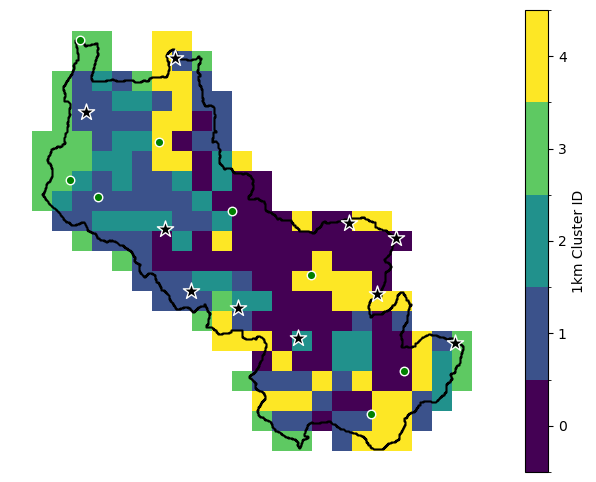

In [80]:
cmap = plt.get_cmap("viridis", 5)

fig, ax = plt.subplots(figsize=(8, 6))

rainfall_gdf_valid.plot(column="cluster", ax=ax, cmap=cmap, norm=norm, legend=False)
catchment_Dolwen.boundary.plot(ax=ax, color="black")

ax.scatter(selected_df["x"], selected_df["y"], c="black", edgecolor="white",
           s=150, marker="*", zorder=5, label="New sites")
gauge_with_cells.plot(ax=ax, color="green", marker=".", markersize=150,
                       edgecolor="white", zorder=5, label="Existing gauges")

# manually add the hatch pattern to the legend (hatch alone won't auto-appear)
hatch_patch = Patch(facecolor="none", edgecolor="black", hatch="///",
                     label=f"Below purity threshold ({purity_threshold})")

# Add legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = plt.colorbar(sm, ax=ax, boundaries=bounds, ticks=range(5))
cbar.set_label("1km Cluster ID")

ax.axis('off');

<div style="background-color: lightblue; border: 2px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
<div style="text-align: left; margin-top: 20px;">
    
--- 
## 7. Evaluate results
---    
    

</div>

---

### How well do the cluster segment the topographical conditions in the catchment?

---

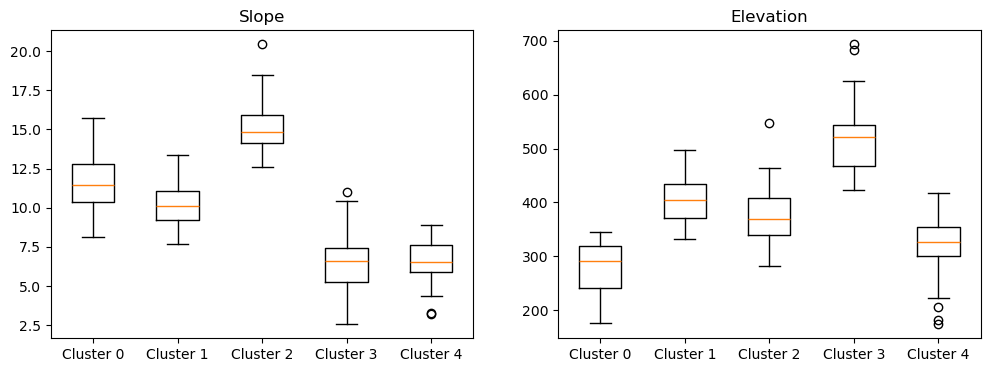

In [82]:
fig, axs = plt.subplots(ncols =2, figsize=(12, 4))
data_by_cluster = [rainfall_gdf_valid.loc[rainfall_gdf_valid["cluster"] == c, "mean_slope"].dropna()
                    for c in range(k)]
axs[0].boxplot(data_by_cluster, tick_labels=[f"Cluster {c}" for c in range(k)])
axs[0].set_title("Slope")

data_by_cluster = [rainfall_gdf_valid.loc[rainfall_gdf_valid["cluster"] == c, "mean_dem"].dropna()
                    for c in range(k)]
axs[1].boxplot(data_by_cluster, tick_labels=[f"Cluster {c}" for c in range(k)])
axs[1].set_title("Elevation");

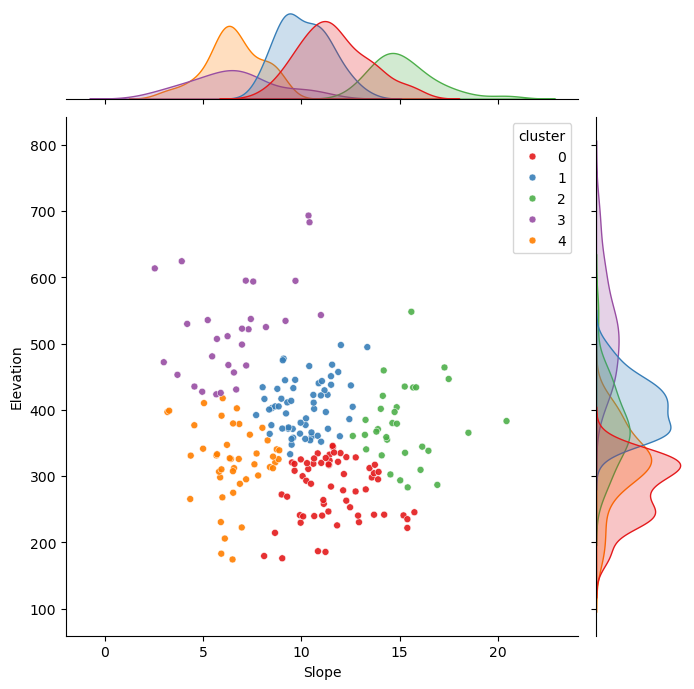

In [92]:
import seaborn as sns

g = sns.jointplot(data=rainfall_gdf_valid, x="mean_slope", y="mean_dem",
    hue="cluster", palette="Set1", alpha=0.9, s=25, height=7)
g.ax_joint.set_xlabel("Slope")
g.ax_joint.set_ylabel("Elevation")
plt.show()

---

### How well do the chosen gauge locations (+ existing gauge locations) represent the full catchment DEM/slope distributions

---

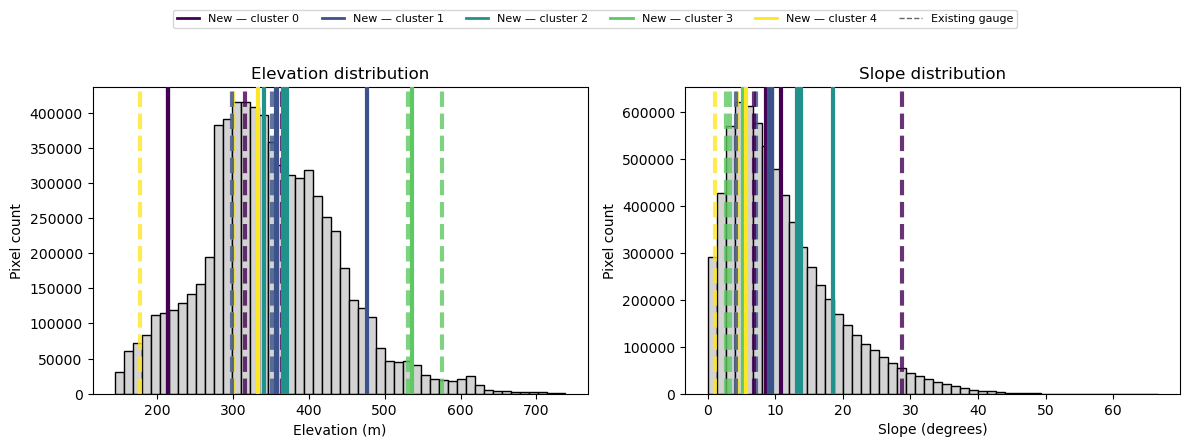

In [81]:
# Get existing gauges' own 30m pixel dem/slope values
gauge_rows, gauge_cols = rasterio.transform.rowcol(
    transform, gauge_with_cells.geometry.x.values, gauge_with_cells.geometry.y.values)

gauge_rows = np.array(gauge_rows)
gauge_cols = np.array(gauge_cols)

gauge_dem = dem_arr[gauge_rows, gauge_cols]
gauge_slope = slope_arr[gauge_rows, gauge_cols]
gauge_clusters = gauge_with_cells["cluster"].values

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

# ---- Elevation ----
axs[0].hist(dem_arr[valid_mask_30m], bins=50, color="lightgray", edgecolor="black", zorder=1)

for _, row in selected_df.iterrows():
    axs[0].axvline(row["dem"], color=cmap(row["cluster"] / (k - 1)),
                    linewidth=3, linestyle="-", zorder=3)

for val, cluster in zip(gauge_dem, gauge_clusters):
    axs[0].axvline(val, color=cmap(cluster / (k - 1)), linewidth=3,
                    linestyle="--", alpha=0.8, zorder=2)

axs[0].set_xlabel("Elevation (m)")
axs[0].set_ylabel("Pixel count")
axs[0].set_title("Elevation distribution")

# ---- Slope ----
axs[1].hist(slope_arr[valid_mask_30m], bins=50, color="lightgray", edgecolor="black", zorder=1)

for _, row in selected_df.iterrows():
    axs[1].axvline(row["slope"], color=cmap(row["cluster"] / (k - 1)),
                    linewidth=3, linestyle="-", zorder=3)

for val, cluster in zip(gauge_slope, gauge_clusters):
    axs[1].axvline(val, color=cmap(cluster / (k - 1)), linewidth=3,
                    linestyle="--", alpha=0.8, zorder=2)

axs[1].set_xlabel("Slope (degrees)")
axs[1].set_ylabel("Pixel count")
axs[1].set_title("Slope distribution")

# ---- Legend ----
cluster_handles = [
    Line2D([0], [0], color=cmap(c / (k - 1)), lw=2, label=f"New — cluster {c}")
    for c in sorted(selected_df["cluster"].unique())]
existing_handle = Line2D([0], [0], color="black", lw=1, linestyle="--", alpha=0.6, label="Existing gauge")
fig.legend(handles=cluster_handles + [existing_handle],
           loc="upper center", ncol=min(len(cluster_handles) + 1, 7),
           bbox_to_anchor=(0.5, 1.12), fontsize=8)

plt.tight_layout()